<a href="https://colab.research.google.com/github/andysanchez1403-droid/ANDREA-GLZ-SNZ/blob/main/TAREA%204_PRUEBA_DE_RACHAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PRUEBAS DE RACHAS**

Para esta prueba se considera la siguiente hipótesis nula:

  $H_0:$ Los números de la muestra {$X_i$] **son independientes**.

luego:

$H_1:$ Los números de la muestra {$X_i$} **no son independientes.**

**PASO 1:**

Determinar la secuencia **S** de 0 y 1 ($^+$ y  $^-$)

así:

Si $X_i$ $\leq$ $X_{i-1}$ escribir 0 (0$^-$)

Si $X_i$  > $X_{i-1}$ escribir 1 (0$^+$)

La secuencia **S** contiene **n-1**números.

S= {--+-+++--+-+...}

**PASO 2:**

Contar el número de rachas observadas **$C_o.$** Una racha viene dada por el número de ceros ($^+$) ó unos ($^-$) consecutivos que le fórmula.

**PASO 3:**

Calcule el valor esperado y la varianza del número de rachas, así como como el estadístico **$Z_0$** mediante:


$\mu_{C_{0}}$= $\frac{2n-1}{3}$


$\sigma^2{C_{0}}$= $\frac{16n-29}{90}$


$Z_0$=  $\frac {C_{0}- \mu_{C_{0}}}{\sigma_{0}}$

Dado que $C_0$ sigue una distribución normal de media $\mu_{C_{0}}$, varianza $\sigma^2{C_{0}}$ y $Z_0$ una distribución normal (0,1). El intervalo de aceptación es:

$-Z_{\alpha/2}$ $\leq$ $Z_0$ $\leq$ $Z_{\alpha/2}$ =



Extraemos los datos de la tabla (TABLA 3.1) que hemos ocupado con anterioridad:

In [5]:
import pandas as pd

# Extraemos el url de Github donde está ubiccado el excel
url = 'https://github.com/andysanchez1403-droid/ANDREA-GLZ-SNZ/raw/main/DATOS.xlsx'

df = pd.read_excel(url, engine='openpyxl')

#**PASO 1:**

Determinamos la secuencia de **S** de 0 y 1.

In [6]:
# Usamos order='F' (estilo Fortran) para leer en orden las columnas, cuando convertimos de columnas a lista la tabla:
datos = df.values.flatten(order='F').tolist()
n = len(datos)

# Determinamos la secuencia S de 0 y 1
# Si Xi <= Xi-1 escribir 0
# Si Xi > Xi-1 escribir 1
S = []
for i in range(1, n):
    if datos[i] <= datos[i-1]:
        S.append(0)
    else:
        S.append(1)

#**PASO 2:**

Contamos el número de rachas, recordando que si hay 2 elementos con signo identico lo contemplamos como uno solo.

In [7]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt


# Contamos las rachas (Co)
Co = 1
for i in range(1, len(S)):
    if S[i] != S[i-1]:
        Co += 1
print(f"Rachas {Co}")

Rachas 70


#**PASO 3:**

Calculamos el valor esperado, varianza del número de rachas, así como el valor estadístico $Z_0$ mediante:

In [8]:
#Calculamos lo ya anterior dicho:
# media = mu
media_Co = (2 * n - 1) / 3
varianza_Co = (16 * n - 29) / 90
desviacion_Co = math.sqrt(varianza_Co)
Z0 = (Co - media_Co) / desviacion_Co


# Imprimimos los resultados:
print("RESULTADOS PRUEBA DE RACHAS")
print(f"Total de datos (n): {n}")
print(f"Rachas observadas (Co): {Co}")
print(f"Media esperada (μCo): {media_Co:.4f}")
print(f"varianza (Co): {varianza_Co}")
print(f"desviacion (Co): {desviacion_Co}")
print(f"Z calculada (Z0): {Z0:.4f}")


if abs(Z0) < 1.96:
    print("DECISIÓN: No se rechaza H0 (Son independientes)")
else:
    print("DECISIÓN: Se rechaza H0 (No son independientes)")



RESULTADOS PRUEBA DE RACHAS
Total de datos (n): 100
Rachas observadas (Co): 70
Media esperada (μCo): 66.3333
varianza (Co): 17.455555555555556
desviacion (Co): 4.1779846284489315
Z calculada (Z0): 0.8776
DECISIÓN: No se rechaza H0 (Son independientes)


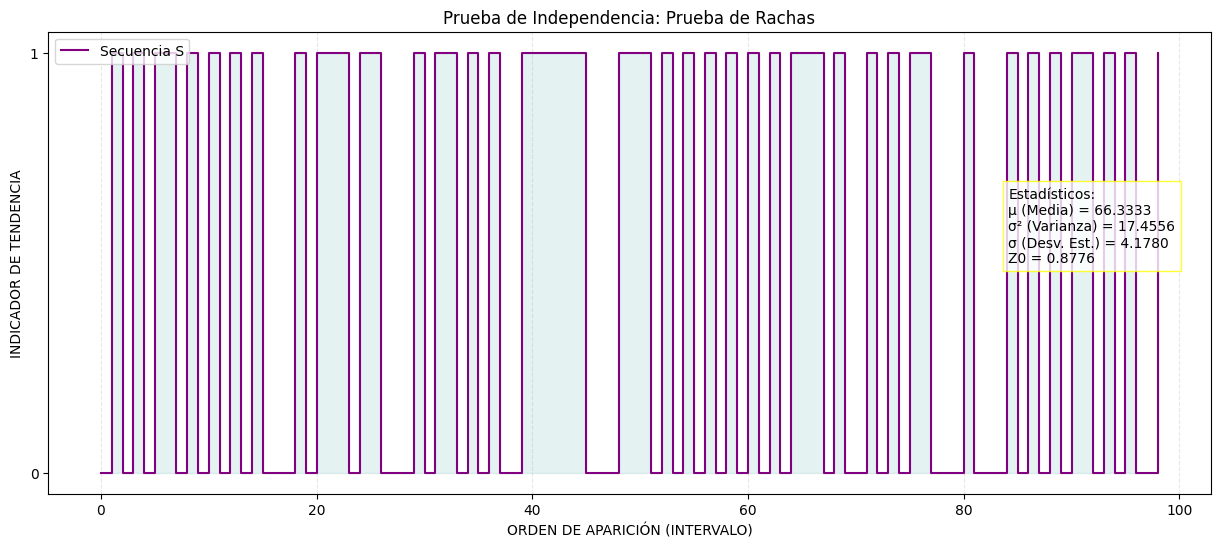

In [22]:
# REALIZAMOS LA GRÁFICA OBSERVANDO LOS DATOS SOLICITADOS CON ANTERIORIDAD
plt.figure(figsize=(15, 6))

# Dibujar la secuencia S
plt.step(range(len(S)), S, where='post', color='purple', linewidth=1.5, label='Secuencia S')
plt.fill_between(range(len(S)), S, step="post", alpha=0.1, color='teal')

# Crear el texto con los estadísticos
info_text = (f"Estadísticos:\n"
             f"μ (Media) = {media_Co:.4f}\n"
             f"σ² (Varianza) = {varianza_Co:.4f}\n"
             f"σ (Desv. Est.) = {desviacion_Co:.4f}\n"
             f"Z0 = {Z0:.4f}")

# Añadir la caja de texto de información
plt.text(len(S)*0.85, 0.5, info_text, fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='yellow'))

# Otros ajustes y más
plt.title('Prueba de Independencia: Prueba de Rachas')
plt.xlabel('ORDEN DE APARICIÓN (INTERVALO)')
plt.ylabel('INDICADOR DE TENDENCIA')
plt.yticks([0, 1], ['0', '1'])
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.show()